# Conclusion of Findings

## Master Thesis: Analyzing Rhetorical Framing in Brexit Debates

This thesis examines rhetorical framing patterns in Brexit-related debates in the UK House of Commons. The analysis combines computational methods with political communication theory to identify and analyze how different frames are used across temporal, party-political, geographical, and demographic dimensions.

The research is based on a comprehensive dataset of parliamentary speeches collected from official UK Parliament records, processed and classified using large language models and machine learning techniques. This conclusion summarizes the key findings from the analysis.

In [7]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

# Locate database
search_roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
for base in search_roots:
    candidate = base / "data/thesis_final.duckdb"
    if candidate.exists():
        db_path = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate `thesis_final.duckdb` in the current or any parent directories."
    )

con = duckdb.connect(database=str(db_path), read_only=True)

## Data Overview
Analysis of Brexit-related speeches in the UK House of Commons (2012-2022) shows systematic variation linked to key political developments during the withdrawal process.

## Key Statistics
- **Average annual volume**: 2,917 speech chunks across 288 debates (~10 speeches per debate)

## Volume Trends
- **2012**: 386 speeches (baseline)
- **2019**: 8,573 speeches (peak)
- **2021-2022**: ~1,000 speeches annually (post-Brexit normalization)

## Interpretation
Speech volume peaked during the political gridlock under the May administration (2018-2019) and declined after:
- Formal UK departure: January 31, 2020
- Trade and Cooperation Agreement: December 2020

## Main Finding
**Inverse relationship between speech volume and political progress**: When executive action stalled, parliamentary discourse intensified. The struggle over framing and interpretation of Brexit escalated precisely when concrete political progress was blocked.

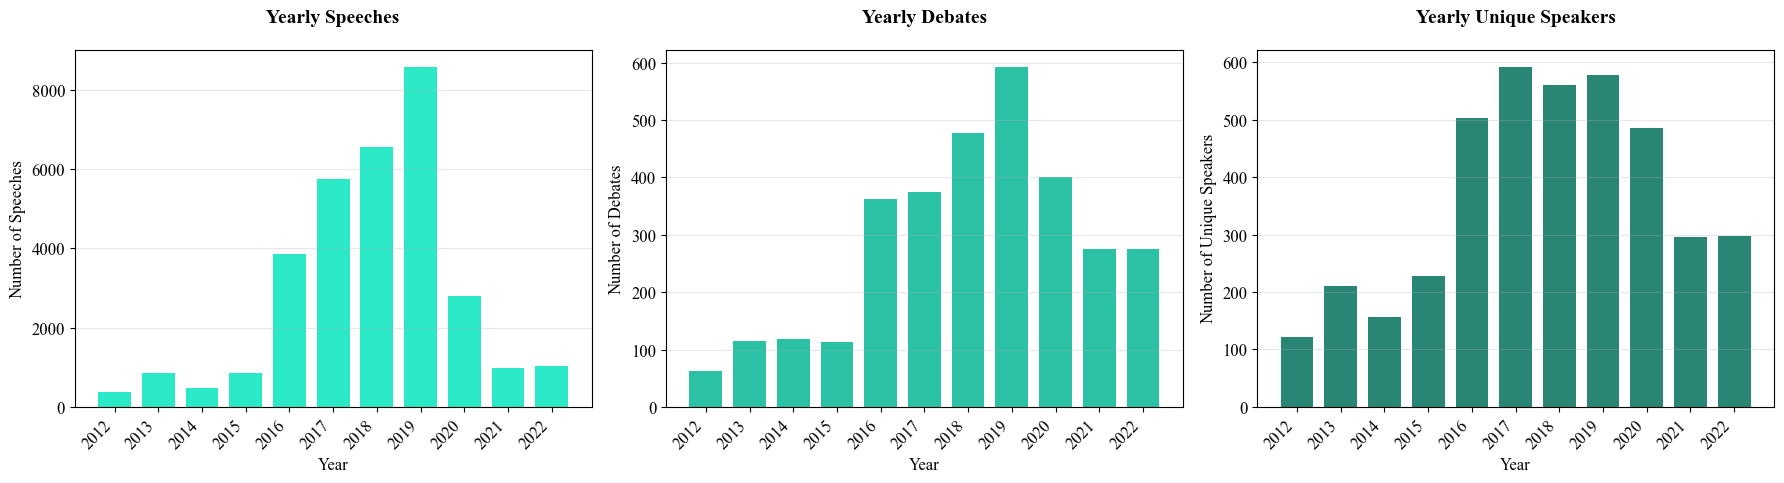

In [9]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

years = yearly_overview["year"].astype(str)
positions = np.arange(len(years))
bar_width = 0.75

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Speeches
axes[0].bar(positions, yearly_overview["speeches"], width=bar_width, color="#06E6BC", alpha=0.85)
axes[0].set_title("Yearly Speeches", fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Number of Speeches", fontsize=12)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(years, rotation=45, ha='right')

# Plot 2: Debates
axes[1].bar(positions, yearly_overview["debates"], width=bar_width, color="#05B696", alpha=0.85)
axes[1].set_title("Yearly Debates", fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Number of Debates", fontsize=12)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(years, rotation=45, ha='right')

# Plot 3: Unique Speakers
axes[2].bar(positions, yearly_overview["unique_speakers"], width=bar_width, color="#03715D", alpha=0.85)
axes[2].set_title("Yearly Unique Speakers", fontsize=14, fontweight='bold', pad=20)
axes[2].set_ylabel("Number of Unique Speakers", fontsize=12)
axes[2].set_xlabel("Year", fontsize=12)
axes[2].tick_params(axis='y', labelsize=12)
axes[2].tick_params(axis='x', labelsize=12)
axes[2].grid(axis="y", alpha=0.3)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(years, rotation=45, ha='right')

plt.tight_layout()
plt.show()